In [137]:
import pandas as pd
import numpy as np
import tensorflow as tf
np.random.seed(42)
tf.random.set_seed(42)
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
import itertools
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Load Data

In [2]:
# Ex_1 - Ex_4
df_ex1 = pd.read_csv('Data/Ex_1.csv')
df_ex2 = pd.read_csv('Data/Ex_2.csv')
df_ex3 = pd.read_csv('Data/Ex_3.csv')
df_ex4 = pd.read_csv('Data/Ex_4.csv')
# Ext_1 - Ext_4
df_ext1 = pd.read_csv('Data/Ext_1.csv')
df_ext2 = pd.read_csv('Data/Ext_2.csv')
df_ext3 = pd.read_csv('Data/Ext_3.csv')
df_ext4 = pd.read_csv('Data/Ext_4.csv')
# ext_Ex_1 - ext_Ex_4
df_ext_ex_1 = pd.read_csv('Data/ext_Ex_1.csv')
df_ext_ex_2 = pd.read_csv('Data/ext_Ex_2.csv')
df_ext_ex_3 = pd.read_csv('Data/ext_Ex_3.csv')
df_ext_ex_4 = pd.read_csv('Data/ext_Ex_4.csv')
# par_Ex_1 - par_Ex_4
df_par_ex_1 = pd.read_csv('Data/par_Ex_1.csv')
df_par_ex_2 = pd.read_csv('Data/par_Ex_2.csv')
df_par_ex_3 = pd.read_csv('Data/par_Ex_3.csv')
df_par_ex_4 = pd.read_csv('Data/par_Ex_4.csv')

# 2. Dataset Preparation

## 2.1 Add new columns `m` and `NC`

In [3]:
# Ex_1 - Ex_4
df_ex1['m'] = 10
df_ex1['NC'] = 32
df_ex2['m'] = 21
df_ex2['NC'] = 32
df_ex3['m'] = 30
df_ex3['NC'] = 32
df_ex4['m'] = 20
df_ex4['NC'] = 32
# Ext_1 - Ext_4
df_ext1['m'] = 10
df_ext1['NC'] = 192
df_ext2['m'] = 21
df_ext2['NC'] = 192
df_ext3['m'] = 30
df_ext3['NC'] = 192
df_ext4['m'] = 20
df_ext4['NC'] = 192
# ext_Ex_1 - ext_Ex_4
df_ext_ex_1['m'] = 10
df_ext_ex_1['NC'] = 96
df_ext_ex_2['m'] = 21
df_ext_ex_2['NC'] = 96
df_ext_ex_3['m'] = 30
df_ext_ex_3['NC'] = 96
df_ext_ex_4['m'] = 20
df_ext_ex_4['NC'] = 96
# par_Ex_1 - par_Ex_4
df_par_ex_1['m'] = 10
df_par_ex_2['m'] = 21
df_par_ex_3['m'] = 30
df_par_ex_4['m'] = 20

## 2.2 Rename columns

In [4]:
df_ex = pd.concat([df_ex1, df_ex2, df_ex3, df_ex4], ignore_index=True)
df_ext = pd.concat([df_ext1, df_ext2, df_ext3, df_ext4], ignore_index=True)
df_ext_ex = pd.concat([df_ext_ex_1, df_ext_ex_2, df_ext_ex_3, df_ext_ex_4], ignore_index=True)
df_par_ex = pd.concat([df_par_ex_1, df_par_ex_2, df_par_ex_3, df_par_ex_4], ignore_index=True)

In [5]:
df_ex.columns

Index(['Unnamed: 0', 'd', '#d-MPs', 'rel_J', 'rel_A', 'rel_B', 'rel_L',
       'rel_Lp', 'rel_K1', 'rel_K2', 'tim_J', 'tim_A', 'tim_B', 'tim_L',
       'tim_Lp', 'tim_K1', 'tim_K2', 'tim_Kd', 'n_LU', 'm', 'NC'],
      dtype='object')

In [6]:
df_ext.columns

Index(['Unnamed: 0', 'd', '#d-MPs', 'rel_Lp', 'rel_K2', 'tim_Lp', 'tim_K2',
       'tim_Kd', 'n_LU', 'm', 'NC'],
      dtype='object')

In [7]:
df_ext_ex.columns

Index(['Unnamed: 0', 'd', '#d-MPs', 'rel_Lp', 'rel_K2', 'tim_Lp', 'tim_K2',
       'tim_Kd', 'n_LU', 'm', 'NC'],
      dtype='object')

In [8]:
df_par_ex.columns

Index(['Unnamed: 0', 'd', 'p', 'n_LU', 'tim_Kd', 'Nc', 'rel_Lp', 'rel_K',
       'tim_Lp', 'tim_K', 'm'],
      dtype='object')

In [9]:
df_par_ex.rename(columns={'Nc': 'NC', 
                          'tim_K': 'tim_K2'},
                 inplace=True)

In [10]:
df_s = [df_ex, df_ext, df_ext_ex]
for df in df_s:
    df.rename(columns={'#d-MPs': 'p'}, inplace=True)

## 2.3 Concat all dataframes

In [11]:
df_raw = pd.concat([df_ex, df_ext, df_ext_ex, df_par_ex], ignore_index=True)

In [12]:
df_raw.columns

Index(['Unnamed: 0', 'd', 'p', 'rel_J', 'rel_A', 'rel_B', 'rel_L', 'rel_Lp',
       'rel_K1', 'rel_K2', 'tim_J', 'tim_A', 'tim_B', 'tim_L', 'tim_Lp',
       'tim_K1', 'tim_K2', 'tim_Kd', 'n_LU', 'm', 'NC', 'rel_K'],
      dtype='object')

## 2.4 Drop unnecessary columns

In [13]:
df_raw.drop(columns=['Unnamed: 0', 'd','rel_J', 'rel_A', 'rel_B', 'rel_L', 'rel_Lp', 'rel_K1', 'rel_K2', 'tim_J', 'tim_A', 'tim_B', 'tim_L','tim_K1','tim_Kd','rel_K'], inplace=True)

In [14]:
df_raw.columns

Index(['p', 'tim_Lp', 'tim_K2', 'n_LU', 'm', 'NC'], dtype='object')

## 2.5 Create `R` column

In [15]:
df_raw['R'] = df_raw['tim_K2'] / df_raw['tim_Lp']

In [16]:
df_raw.head()

,p,tim_Lp,tim_K2,n_LU,m,NC,R
0,50,0.529260,0.972090,66.0,10,32,1.836697
1,105,0.590286,1.019429,140.0,10,32,1.727009
2,196,0.640274,1.070483,260.0,10,32,1.671914
3,1210,2.259156,2.985669,1530.0,10,32,1.321586
4,137,0.650689,1.121289,294.0,21,32,1.723234


## 2.6 Drop columns: `tim_Lp`, `tim_K2`

In [17]:
df_raw.drop(columns=['tim_Lp','tim_K2'], inplace=True)

In [18]:
df_raw.head()

,p,n_LU,m,NC,R
0,50,66.0,10,32,1.836697
1,105,140.0,10,32,1.727009
2,196,260.0,10,32,1.671914
3,1210,1530.0,10,32,1.321586
4,137,294.0,21,32,1.723234


In [19]:
df = df_raw.copy()

# 3. Dataset overwiew & Summary Statistics

In [20]:
df.head(10)

,p,n_LU,m,NC,R
0,50,66.0,10,32,1.836697
1,105,140.0,10,32,1.727009
2,196,260.0,10,32,1.671914
3,1210,1530.0,10,32,1.321586
4,137,294.0,21,32,1.723234
5,737,1612.0,21,32,0.875098
6,3047,6494.0,21,32,0.841370
7,10439,21394.0,21,32,0.862585
8,88,192.0,30,32,0.744993
9,2573,6750.0,30,32,0.523750


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   p       150 non-null    int64  
 1   n_LU    150 non-null    float64
 2   m       150 non-null    int64  
 3   NC      150 non-null    int64  
 4   R       150 non-null    float64
dtypes: float64(2), int64(3)
memory usage: 6.0 KB


In [22]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
p,150.0,4430.000000,9939.206084,50.000000,137.00000,737.000000,3047.000000,40140.000000
n_LU,150.0,10686.600000,27174.951709,66.000000,197.00000,1530.000000,6750.000000,110007.000000
m,150.0,19.600000,6.862015,10.000000,10.00000,20.000000,21.000000,30.000000
NC,150.0,43.200000,55.576539,4.000000,12.00000,22.000000,32.000000,192.000000
R,150.0,1.372228,1.291535,0.229617,0.87528,1.189791,1.426601,10.459036


In [23]:
df.shape

(150, 5)

# 4. Data Quality Audit

In [24]:
class DataQualityCheck:
    def __init__(self, dataframe):
        self.df = dataframe
    def check_missing_values(self):
        pct = (self.df.isnull().sum() / len(self.df) ) * 100
        return pct[pct > 0]
    def check_duplicates(self):
        duplicates = self.df.duplicated().sum()
        return f"Numbers of duplicated rows: {duplicates}"

In [25]:
check_df = DataQualityCheck(df)
check_df.check_missing_values()

Series([], dtype: float64)

In [26]:
check_df.check_duplicates()

'Numbers of duplicated rows: 0'

**Insights:**  
Dataset not included missing values and duplicates.

# 5. Univariate Analysis

In [27]:
def histplots(df, cols, n, m, sup_title):
    sns.set_style('whitegrid')
    fig, axes = plt.subplots(nrows=n, ncols=m, figsize=(15,10))
    plt.suptitle(sup_title)
    axes = axes.flatten()
    for i, col in enumerate(cols):
        sns.histplot(data=df, x=col, kde=True, bins=20, ax=axes[i])
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')
    for j in range(len(cols), n * m):
        axes[j].set_visible(False)
    plt.tight_layout()
    plt.show()
def scatter(df, x, y):
    sns.set_style('whitegrid')
    plt.figure(figsize=(10,8))
    sns.scatterplot(data = df, x=x, y=y)
    plt.title('p vs R logarithmic scale')
    plt.show()

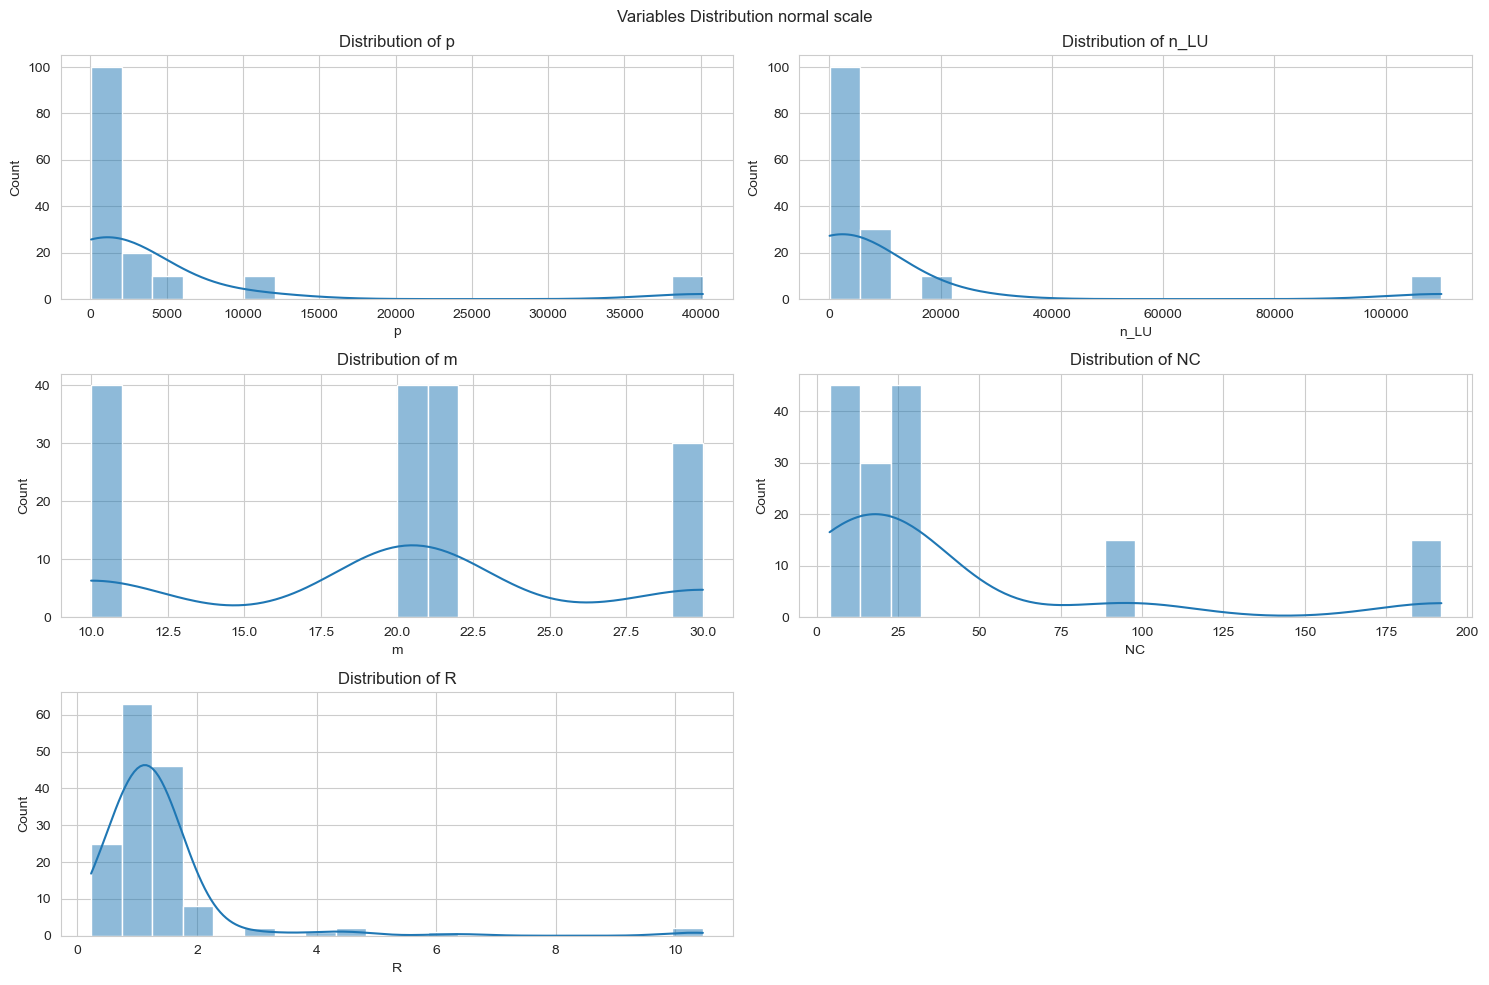

In [28]:
histplots(df, df.columns, 3,2, 'Variables Distribution normal scale')

**Insights:**  


## 5.1 Change to logarithmic scale

In [29]:
df_log = pd.DataFrame()
df_log['p_log'] = np.log(df['p'])
df_log['n_LU_log'] = np.log(df['n_LU'])
df_log['m_log'] = np.log(df['m'])
df_log['NC_log'] = np.log(df['NC'])
df_log['R_log'] = np.log(df['R'])

In [30]:
df_log.head()

,p_log,n_LU_log,m_log,NC_log,R_log
0,3.912023,4.189655,2.302585,3.465736,0.607969
1,4.653960,4.941642,2.302585,3.465736,0.546391
2,5.278115,5.560682,2.302585,3.465736,0.513969
3,7.098376,7.333023,2.302585,3.465736,0.278833
4,4.919981,5.683580,3.044522,3.465736,0.544203


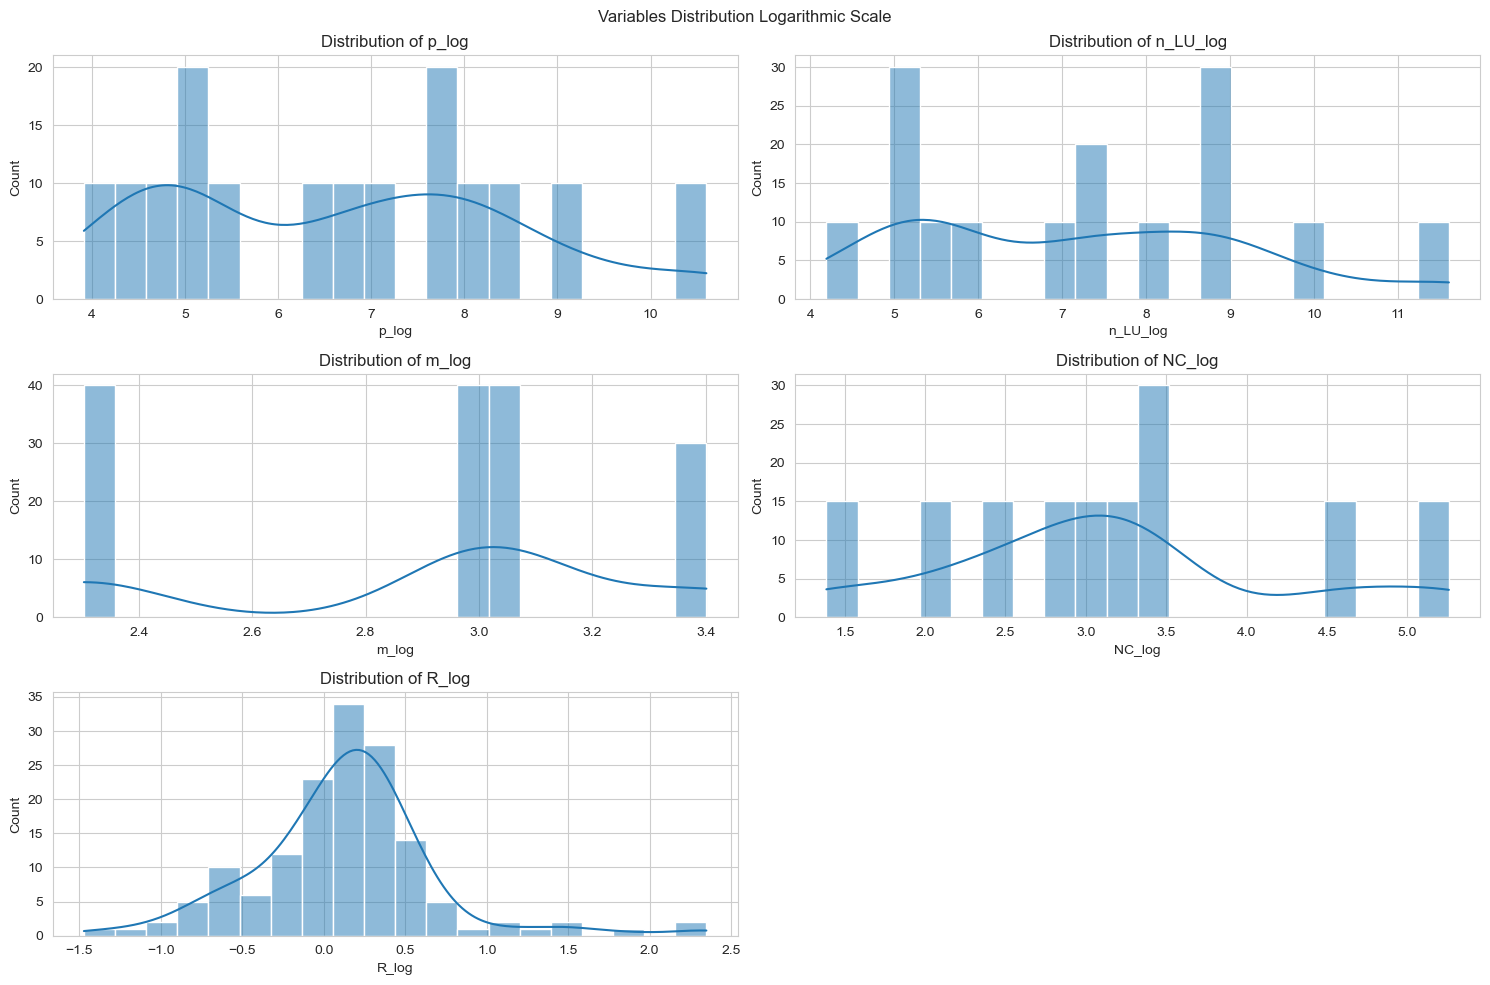

In [31]:
histplots(df_log, df_log.columns, 3,2, 'Variables Distribution Logarithmic Scale')

**Insights:**  

# 6. Bivariate Analysis

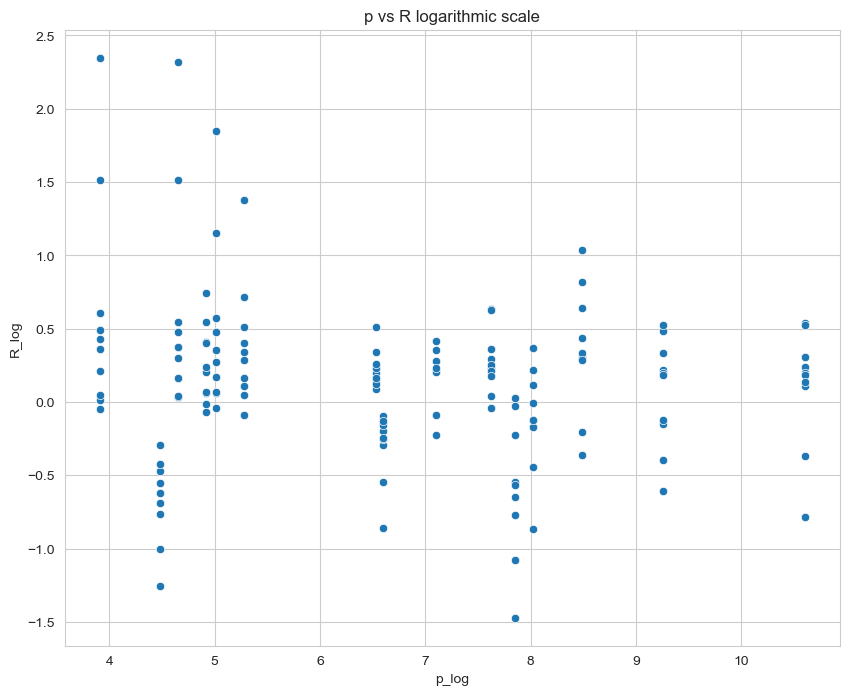

In [32]:
scatter(df_log, df_log['p_log'], df_log['R_log'])

In [33]:
df_log[df_log['p_log'] <= 5].shape[0]

40

In [34]:
df_final = df_log[df_log['p_log'] > 5]

**Insights:**

# 7. Training models

## 7.1 Split data

In [35]:
X = df_final[['m_log', 'p_log', 'n_LU_log', 'NC_log']].values
y = df_final['R_log'].values

## 7.2 First Model

In [36]:
def build_model():
    inputs = layers.Input(shape=(4,))
    x = layers.Dense(128, activation='relu')(inputs)
    x = layers.Dense(64, activation='relu') (x)
    x = layers.Dense(32, activation='relu')(x)
    outputs = layers.Dense(1, activation='linear')(x)
    model = keras.Model(inputs = inputs, outputs = outputs)
    return model

In [37]:
model = build_model()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 4)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,009 (43.00 KB)

 Trainable params: 11,009 (43.00 KB)

 Non-trainable params: 0 (0.00 B)

## 7.2 Second Model

In [38]:
def build_model_v2():
    inputs = layers.Input(shape=(4,))
    x = layers.Dense(64, activation='relu')(inputs)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dense(16, activation='relu')(x)
    outputs = layers.Dense(1, activation='linear')(x)
    model = keras.Model(inputs = inputs, outputs = outputs)
    return model
model_v2 = build_model_v2()
model_v2.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 4)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,945 (11.50 KB)

 Trainable params: 2,945 (11.50 KB)

 Non-trainable params: 0 (0.00 B)

## 7.3 Third Model

In [39]:
def build_model_v3():
    inputs = layers.Input(shape=(4,))
    x = layers.Dense(256, activation='relu')(inputs)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dense(32, activation='relu')(x)
    outputs = layers.Dense(1, activation='linear')(x)
    model = keras.Model(inputs = inputs, outputs = outputs)
    return model
model_v3 = build_model_v3()
model_v3.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 4)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 256)                 │           1,280 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 44,545 (174.00 KB)

 Trainable params: 44,545 (174.00 KB)

 Non-trainable params: 0 (0.00 B)

## 7.4 Fourth Model

In [40]:
def build_model_v4():
    inputs = layers.Input(shape=(4,))
    x = layers.Dense(64, activation='relu')(inputs)
    x = layers.Dense(32, activation='relu')(x)
    outputs = layers.Dense(1, activation='linear')(x)
    model = keras.Model(inputs = inputs, outputs = outputs)
    return model
model_v4 = build_model_v4()
model_v4.summary()
    

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)           │ (None, 4)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 64)                  │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,433 (9.50 KB)

 Trainable params: 2,433 (9.50 KB)

 Non-trainable params: 0 (0.00 B)

## 7.5 Train Model Function

In [41]:
scaler = StandardScaler()
def train_model(build_fn, kf, epochs, batch_size, optimizer):
    results = []
    histories = []
    for train_idx, val_idx in kf.split(X):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        X_train_scaled = scaler.fit_transform(X_train)
        X_val_scaled = scaler.transform(X_val)
        model = build_fn()
        model.compile(optimizer=optimizer, loss = 'mse', metrics=['mae'])
        history = model.fit(X_train_scaled, y_train, epochs=epochs, batch_size=batch_size,validation_data = (X_val_scaled, y_val), verbose=0)
        result = model.evaluate(X_val_scaled, y_val, verbose=0)
        results.append({'mse': result[0], 'mae': result[1]})
        histories.append(history)
    return pd.DataFrame(results), histories
        

## 7.6 3-Fold Validation

In [42]:
kf = KFold(n_splits = 3, shuffle = True, random_state = 42)

In [43]:
# Optimizer `adam`, epochs = 200, batch_size = 8
results_v1_1, histories_v1_3_1 = train_model(build_model, kf, 200, 8, 'adam')
results_v2_1, histories_v2_3_1  = train_model(build_model_v2, kf, 200, 8, 'adam')
results_v3_1, histories_v3_3_1  = train_model(build_model_v3, kf, 200, 8, 'adam')
results_v4_1, histories_v4_3_1  = train_model(build_model_v4, kf, 200, 8, 'adam')
# Optimizer `rmsprop`, epochs = 200, batch_size 8
results_v1_2, histories_v1_3_2  = train_model(build_model, kf, 200, 8, 'rmsprop')
results_v2_2, histories_v2_3_2  = train_model(build_model_v2, kf, 200, 8, 'rmsprop')
results_v3_2, histories_v3_3_2  = train_model(build_model_v3, kf, 200, 8, 'rmsprop')
results_v4_2, histories_v4_3_2  = train_model(build_model_v4, kf, 200, 8, 'rmsprop')


In [44]:
results_v1_1.loc['mean'] = results_v1_1.mean()
results_v2_1.loc['mean'] = results_v2_1.mean()
results_v3_1.loc['mean'] = results_v3_1.mean()
results_v4_1.loc['mean'] = results_v4_1.mean()
results_v1_2.loc['mean'] = results_v1_2.mean()
results_v2_2.loc['mean'] = results_v2_2.mean()
results_v3_2.loc['mean'] = results_v3_2.mean()
results_v4_2.loc['mean'] = results_v4_2.mean()

|Model (epochs = 200, batch_size = 8, K-Fold = 3)|Mean MAE|
|:---:|:---:|
|Model v1 `adam`|0.1072|
|Model v2 `adam`|0.1238|
|Model v3 `adam`|0.1203|
|Model v4 `adam`|0.1183|
|Model v1 `rmsprop`|0.1204|
|Model v2 `rmsprop`|0.1135|
|Model v3 `rmsprop`|0.1339|
|Model v4 `rmsprop`|0.1244|

## 7.7 5-Fold Validation

In [45]:
kf_2 = KFold(n_splits = 5, shuffle = True, random_state = 42)

In [46]:
# Optimizer `adam`, epochs = 200, batch_size = 8
results_v1_1_5, histories_v1_5_1 = train_model(build_model, kf_2, 200, 8, 'adam')
results_v2_1_5, histories_v2_5_1 = train_model(build_model_v2, kf_2, 200, 8, 'adam')
results_v3_1_5, histories_v3_5_1 = train_model(build_model_v3, kf_2, 200, 8, 'adam')
results_v4_1_5, histories_v4_5_1 = train_model(build_model_v4, kf_2, 200, 8, 'adam')
# Optimizer `rmsprop`, epochs = 200, batch_size 8
results_v1_2_5, histories_v1_5_2 = train_model(build_model, kf_2, 200, 8, 'rmsprop')
results_v2_2_5, histories_v2_5_2 = train_model(build_model_v2, kf_2, 200, 8, 'rmsprop')
results_v3_2_5, histories_v3_5_2 = train_model(build_model_v3, kf_2, 200, 8, 'rmsprop')
results_v4_2_5, histories_v4_5_2 = train_model(build_model_v4, kf_2, 200, 8, 'rmsprop')

In [47]:
results_v1_1_5.loc['mean'] = results_v1_1_5.mean()
results_v2_1_5.loc['mean'] = results_v2_1_5.mean()
results_v3_1_5.loc['mean'] = results_v3_1_5.mean()
results_v4_1_5.loc['mean'] = results_v4_1_5.mean()
results_v1_2_5.loc['mean'] = results_v1_2_5.mean()
results_v2_2_5.loc['mean'] = results_v2_2_5.mean()
results_v3_2_5.loc['mean'] = results_v3_2_5.mean()
results_v4_2_5.loc['mean'] = results_v4_2_5.mean()

In [75]:
results_v2_2_5

,mse,mae
0,0.031727,0.095929
1,0.015827,0.098276
2,0.044801,0.146843
3,0.025710,0.107871
4,0.017223,0.091060
mean,0.027058,0.107996


|Model (epochs = 200, batch_size = 8, K-Fold = 5)|Mean MAE|
|:---:|:---:|
|Model v1 `adam`|0.1083|
|Model v2 `adam`|0.1133|
|Model v3 `adam`|0.1182|
|Model v4 `adam`|0.1122|
|Model v1 `rmsprop`|0.1208|
|Model v2 `rmsprop`|0.1079|
|Model v3 `rmsprop`|0.1249|
|Model v4 `rmsprop`|0.1130|

## 7.8 Overfitting Analysis

In [72]:
def plot(best_fold, histories,nr):
    plt.figure(figsize=(12,10))
    plt.plot(histories[best_fold].history['loss'], label='train')
    plt.plot(histories[best_fold].history['val_loss'], label='val')
    plt.title(f'Training vs Validation Loss — Model no. {nr}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

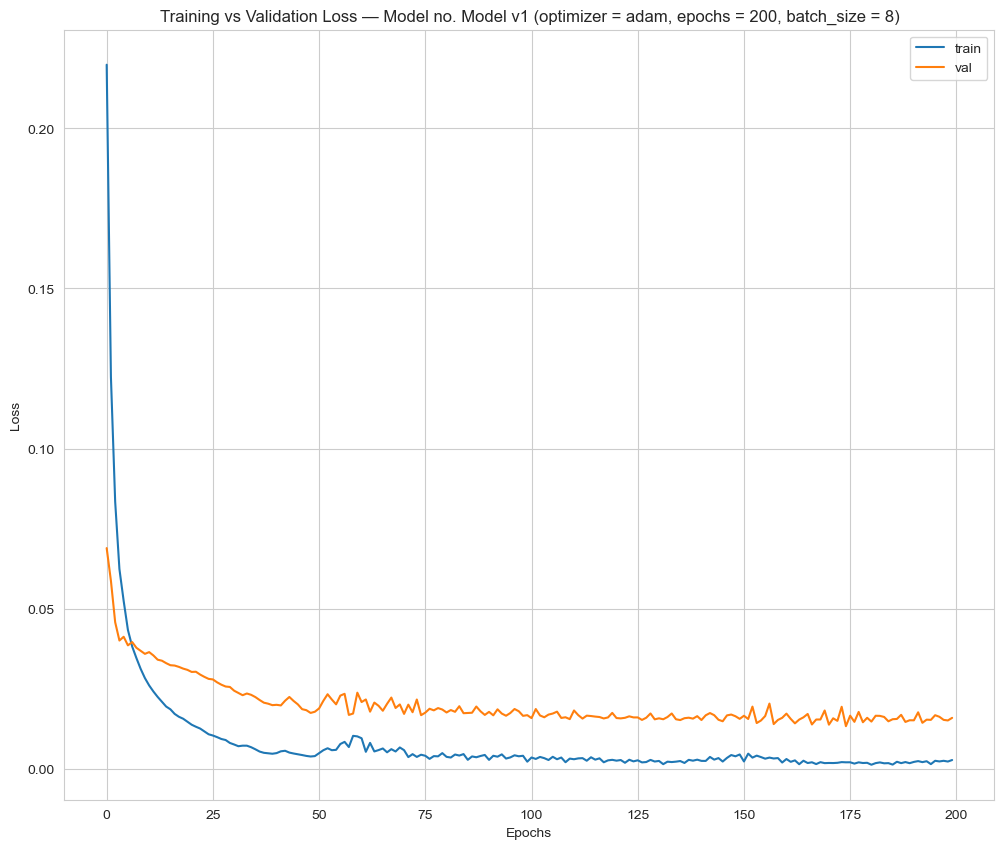

In [73]:
best_fold_v1_adam = results_v1_1_5['mae'].idxmin()
plot(best_fold_v1_adam, histories_v1_5_1, 'Model v1 (optimizer = adam, epochs = 200, batch_size = 8)')

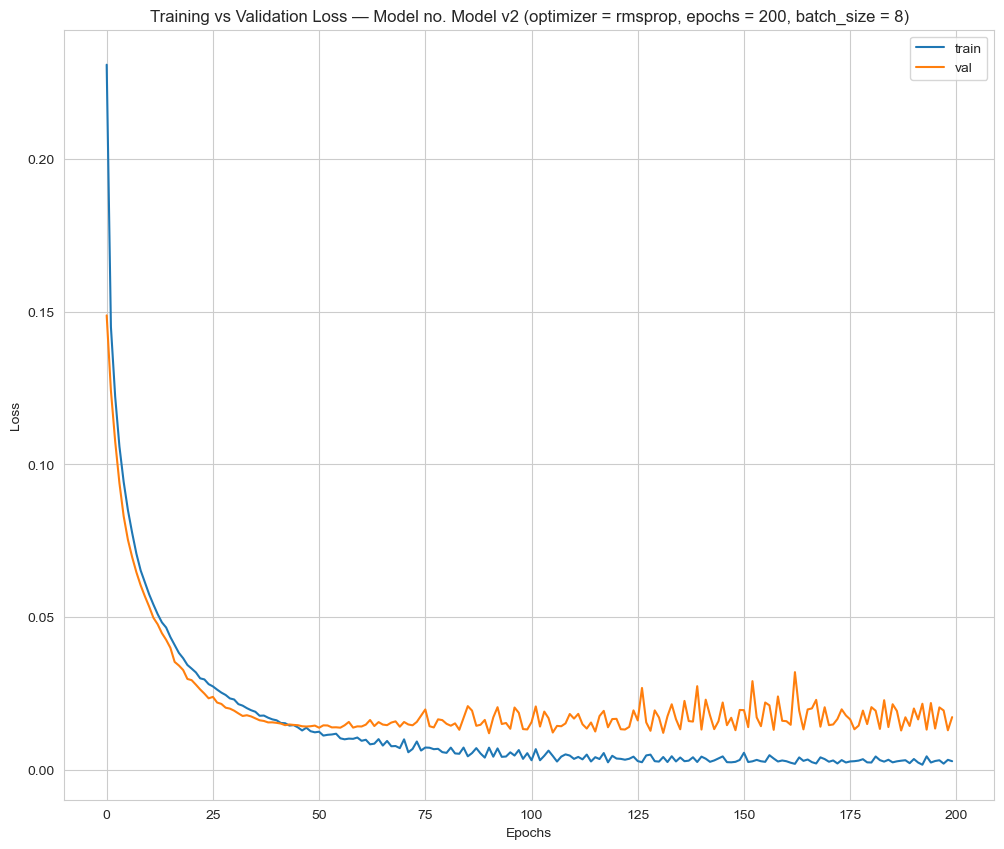

In [74]:
best_fold_v2_rmsprop = results_v2_2_5['mae'].idxmin()
plot(best_fold_v2_rmsprop, histories_v2_5_2, 'Model v2 (optimizer = rmsprop, epochs = 200, batch_size = 8)')

**Conclusion:**  


## 7.9 Testing different epochs and batch_size

In [76]:
# epochs = 100, batch_size = 4, K-Fold = 5
final_results_1, histories_1 = train_model(build_model_v2, kf_2, 100, 4, 'rmsprop')
# epochs = 100, batch_size = 8, K-Fold = 5
final_results_2, histories_2 = train_model(build_model_v2, kf_2, 100, 8, 'rmsprop')
# # epochs = 100, batch_size = 16, K-Fold = 5
final_results_3, histories_3 = train_model(build_model_v2, kf_2, 100, 16, 'rmsprop')
# # epochs = 100, batch_size = 32, K-Fold = 5
final_results_4, histories_4 = train_model(build_model_v2, kf_2, 100, 32, 'rmsprop')
# epochs = 125, batch_size = 4, K-Fold = 5
final_results_5,  histories_5 = train_model(build_model_v2, kf_2, 125, 4, 'rmsprop')
# epochs = 125, batch_size = 8, K-Fold = 5
final_results_6,  histories_6 = train_model(build_model_v2, kf_2, 125, 8, 'rmsprop')
# epochs = 125, batch_size = 16, K-Fold = 5
final_results_7,  histories_7 = train_model(build_model_v2, kf_2, 125, 16, 'rmsprop')
# epochs = 125, batch_size = 32, K-Fold = 5
final_results_8,  histories_8 = train_model(build_model_v2, kf_2, 125, 32, 'rmsprop')
# epochs = 150, batch_size = 4, K-Fold = 5
final_results_9,  histories_9 = train_model(build_model_v2, kf_2, 150, 4, 'rmsprop')
# epochs = 150, batch_size = 8, K-Fold = 5
final_results_10,  histories_10 = train_model(build_model_v2, kf_2, 150, 8, 'rmsprop')
# epochs = 150, batch_size = 16, K-Fold = 5
final_results_11,  histories_11 = train_model(build_model_v2, kf_2, 150, 16, 'rmsprop')
# epochs = 150, batch_size = 4, K-Fold = 5
final_results_12,  histories_12 = train_model(build_model_v2, kf_2, 150, 32, 'rmsprop')


In [78]:
final_results_1.loc['mean'] = final_results_1.mean()
final_results_2.loc['mean'] = final_results_2.mean()
final_results_3.loc['mean'] = final_results_3.mean()
final_results_4.loc['mean'] = final_results_4.mean()
final_results_5.loc['mean'] = final_results_5.mean()
final_results_6.loc['mean'] = final_results_6.mean()
final_results_7.loc['mean'] = final_results_7.mean()
final_results_8.loc['mean'] = final_results_8.mean()
final_results_9.loc['mean'] = final_results_9.mean()
final_results_10.loc['mean'] = final_results_10.mean()
final_results_11.loc['mean'] = final_results_11.mean()
final_results_12.loc['mean'] = final_results_12.mean()

|Lp|Epochs|Batch_size|Mean MAE|
|:---:|:---:|:---:|:---:|
|1|100|4|0.1148|
|2|100|8|0.1150|
|3|100|16|0.1243|
|4|100|32|0.1273|
|5|125|4|0.1119|
|6|125|8|0.1085|
|7|125|16|0.1165|
|8|125|32|0.1203|
|9|150|4|0.1069|
|10|150|8|0.1098|
|11|150|16|0.1107|
|12|150|32|0.1123|

**Conclusion:**  

## 7.10 Overfitting Analysis

In [91]:
# Best folds for models
best_fold_6 = final_results_6['mae'].idxmin()
best_fold_9 = final_results_9['mae'].idxmin()
best_fold_10 = final_results_10['mae'].idxmin()

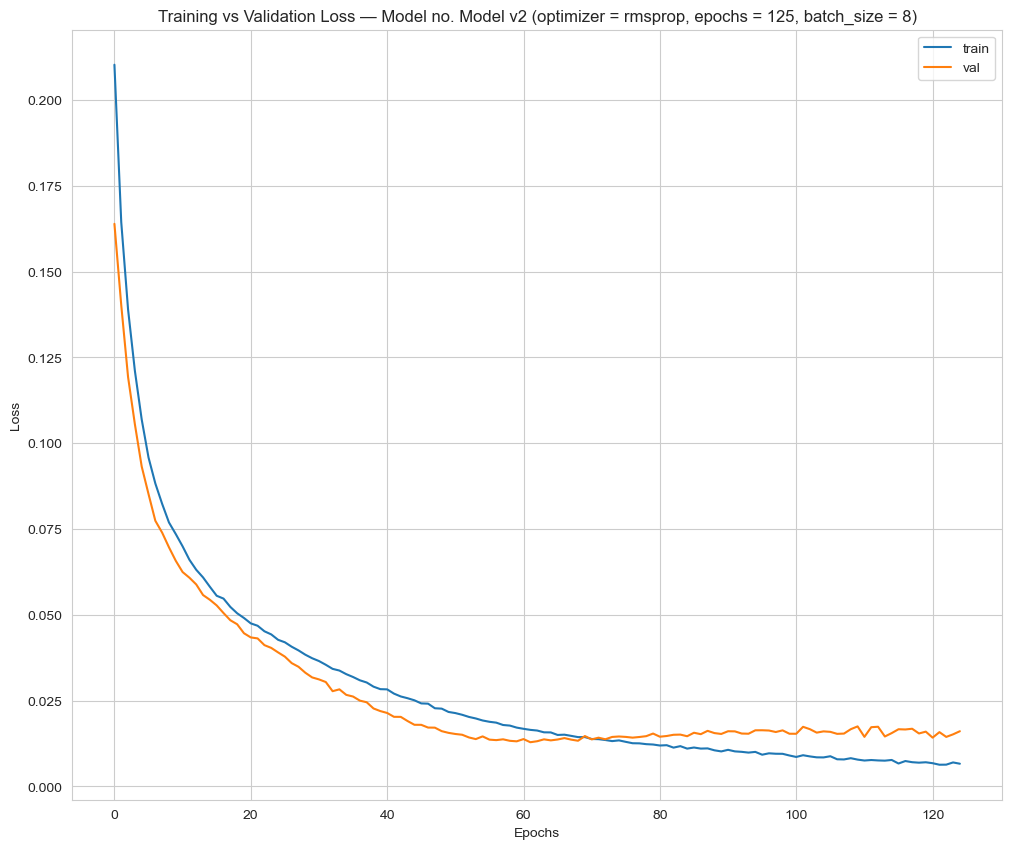

In [92]:
plot(best_fold_6, histories_6, 'Model v2 (optimizer = rmsprop, epochs = 125, batch_size = 8)')

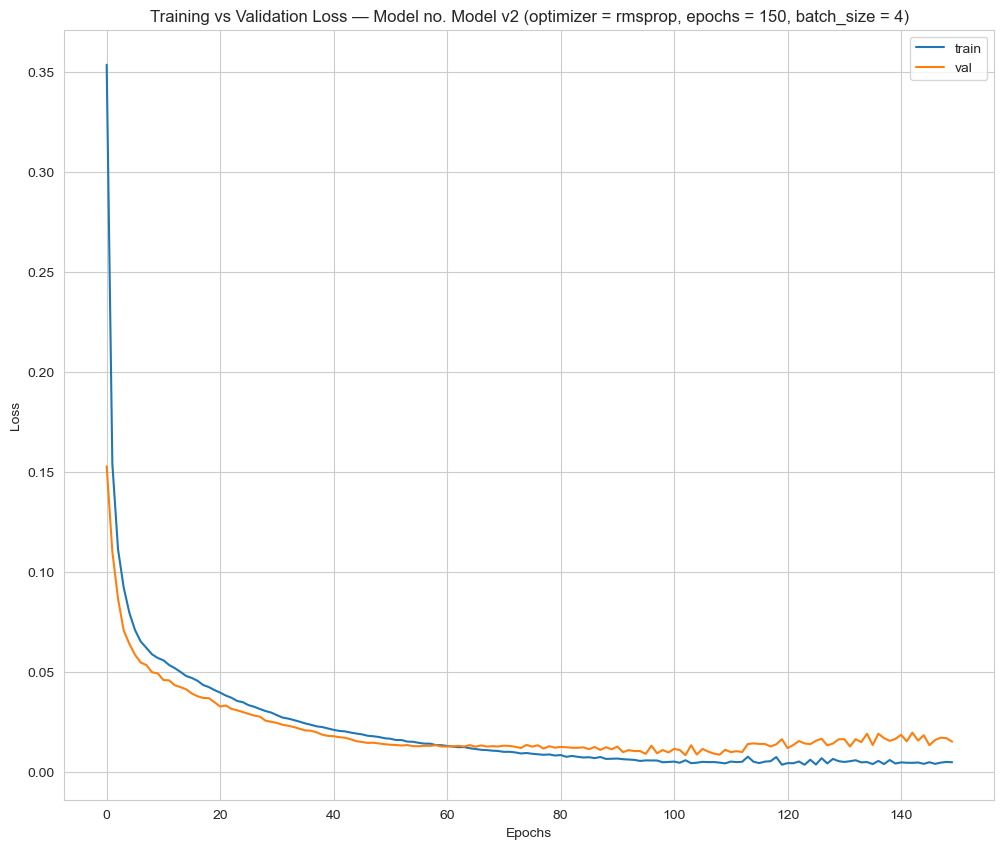

In [93]:
plot(best_fold_9, histories_9, 'Model v2 (optimizer = rmsprop, epochs = 150, batch_size = 4)')

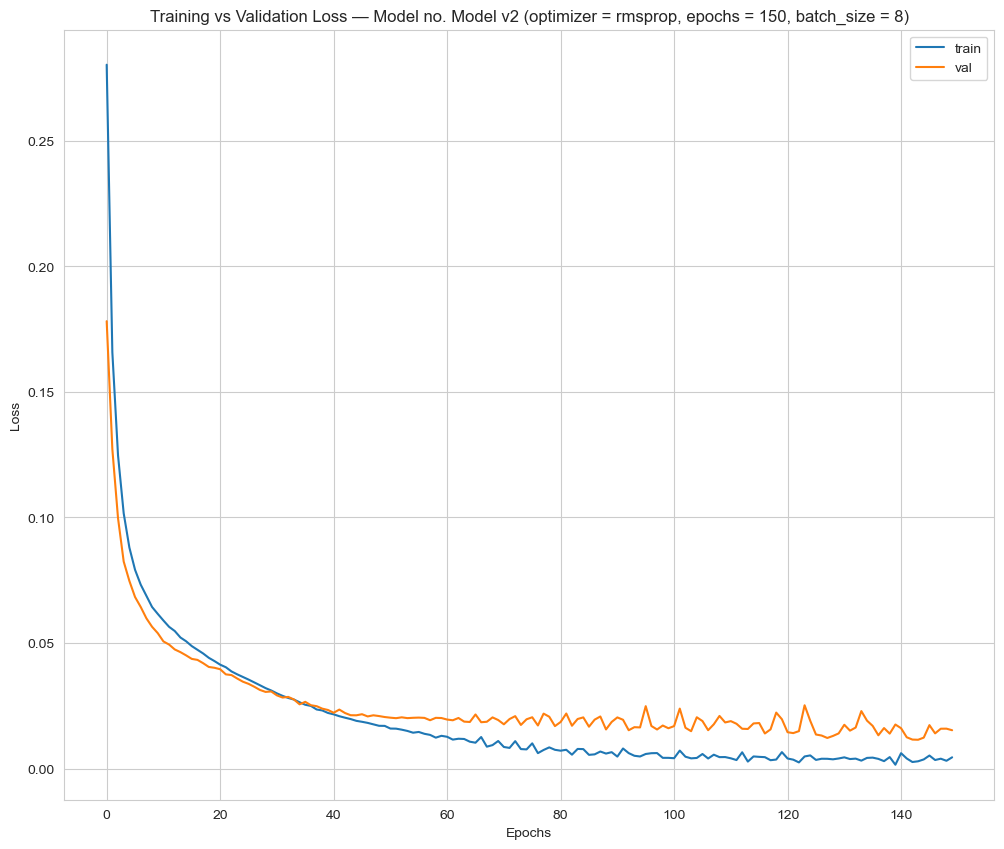

In [94]:
plot(best_fold_10, histories_10, 'Model v2 (optimizer = rmsprop, epochs = 150, batch_size = 8)')

**Conclusion:**  

## 7.11 Final Hyperparameter Selection

In [103]:
best_model_results, best_history = train_model(build_model_v2,kf_2, 80, 4, 'rmsprop')

In [104]:
best_model_results.loc['mean'] = best_model_results.mean()

In [105]:
best_model_results

,mse,mae
0,0.032080,0.106012
1,0.015956,0.101825
2,0.065409,0.146713
3,0.014737,0.088014
4,0.009825,0.079342
mean,0.027601,0.104381


In [106]:
best_fold_final = best_model_results['mae'].idxmin()

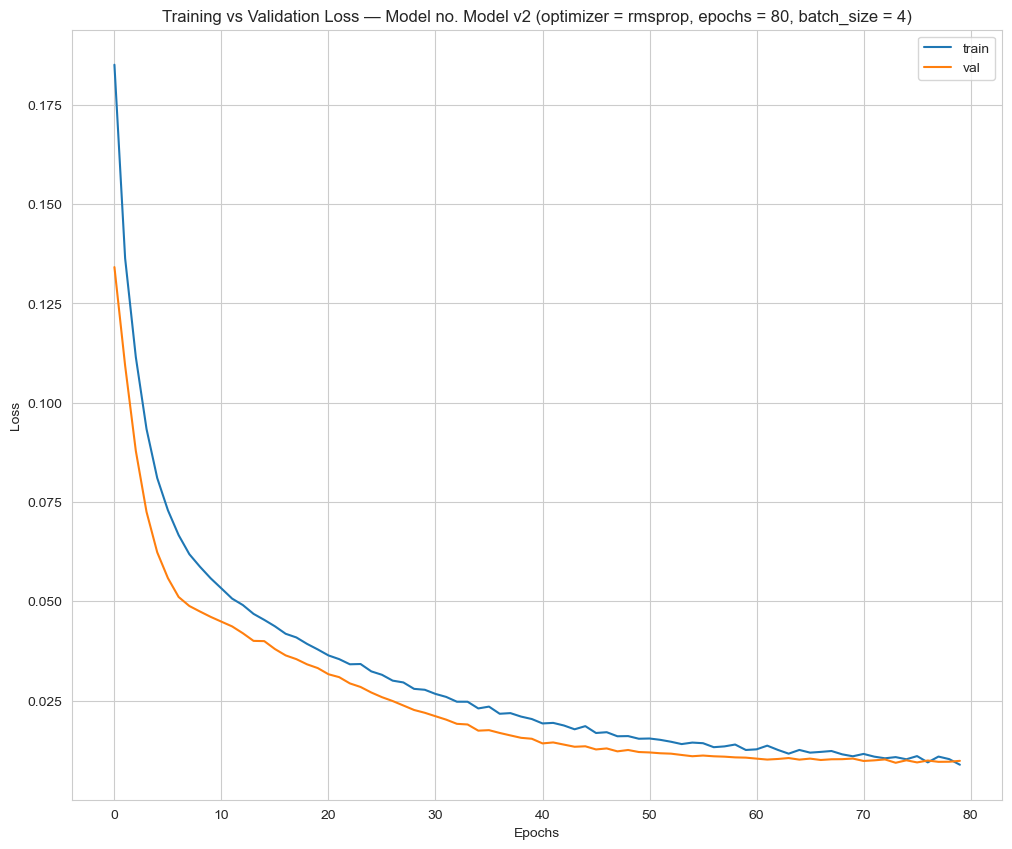

In [108]:
plot(best_fold_final, best_history, 'Model v2 (optimizer = rmsprop, epochs = 80, batch_size = 4)')

**Conclusion:**  


# 8.Final Model Training

In [109]:
final_model = build_model_v2()

In [110]:
final_model.compile(
    optimizer='rmsprop',
    loss = 'mse',
    metrics = ['mae']
)

In [111]:
final_model.fit(X, y,
          epochs = 80,
          batch_size = 4,
          verbose = 0
         )

# 9. Predictions for NC ∈ {64, 128, 256, 512, 1024}

## 9.1 Data Preparation for Predictions

In [114]:
df_final.columns

Index(['p_log', 'n_LU_log', 'm_log', 'NC_log', 'R_log'], dtype='object')

In [124]:
nc_values_raw = [64, 128, 256, 512, 1024]
nc_values_log = np.log(nc_values_raw)
unique_combinations = df_final[['p_log', 'n_LU_log', 'm_log']].drop_duplicates()
predict_data = []
for _, row in unique_combinations.iterrows():
    for nc_log in nc_values_log:
        predict_data.append({
            'p_log': row['p_log'],
            'n_LU_log': row['n_LU_log'],
            'm_log' : row['m_log'],
            'NC_log': nc_log
        })
df_predict = pd.DataFrame(predict_data)
df_predict.head(5)
X_predict = df_predict
X_predict.columns

Index(['p_log', 'n_LU_log', 'm_log', 'NC_log'], dtype='object')

In [125]:
X_final = df_final[['p_log','n_LU_log', 'm_log', 'NC_log']]
y_final = df_final['R_log']
X_final_scaled = scaler.fit_transform(X_final)
X_predict_scaled = scaler.transform(X_predict)

## 9.2 Predictions

In [126]:
model_p = build_model_v2()
model_p.compile(
    optimizer = 'rmsprop',
    loss = 'mse',
    metrics = ['mae']
)
model_p.fit(X_final_scaled, y_final, 
            epochs = 80, 
            batch_size = 80,
            verbose = 0)

In [127]:
y_pred_log = model_p.predict(X_predict_scaled)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


In [133]:
df_predict_normal = pd.DataFrame()

In [134]:
df_predict_normal['p'] = np.exp(df_predict['p_log'])
df_predict_normal['n_LU'] = np.exp(df_predict['n_LU_log'])
df_predict_normal['m'] = np.exp(df_predict['m_log'])
df_predict_normal['NC'] = np.exp(df_predict['NC_log'])
df_predict_normal['Predicted_R'] = np.exp(y_pred_log)

In [153]:
df_predict_normal['m'] = df_predict_normal['m'].round().astype(int)
df_predict_normal['NC'] = df_predict_normal['NC'].round().astype(int)

## 9.3 Results 

In [136]:
df_predict_normal.head(10)

,p,n_LU,m,NC,Predicted_R
0,196.0,260.0,10.0,64.0,2.088440
1,196.0,260.0,10.0,128.0,3.029615
2,196.0,260.0,10.0,256.0,4.041163
3,196.0,260.0,10.0,512.0,3.953479
4,196.0,260.0,10.0,1024.0,3.711002
5,1210.0,1530.0,10.0,64.0,1.029312
6,1210.0,1530.0,10.0,128.0,0.851667
7,1210.0,1530.0,10.0,256.0,0.810655
8,1210.0,1530.0,10.0,512.0,0.907138
9,1210.0,1530.0,10.0,1024.0,1.003689


In [142]:
y_pred_train = model_p.predict(X_final_scaled)
y_final_normal = np.exp(y_final)
y_pred_train_normal = np.exp(y_pred_train)
mae = mean_absolute_error(y_final_normal, y_pred_train_normal)
r2 = r2_score(y_final, y_pred_train)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [143]:
print(f"Mean Absolute Error: {mae:.4f}")
print(f"R2: {r2:.4f}")

Mean Absolute Error: 0.0998
R2: 0.9394


### 9.3.1  Visualization

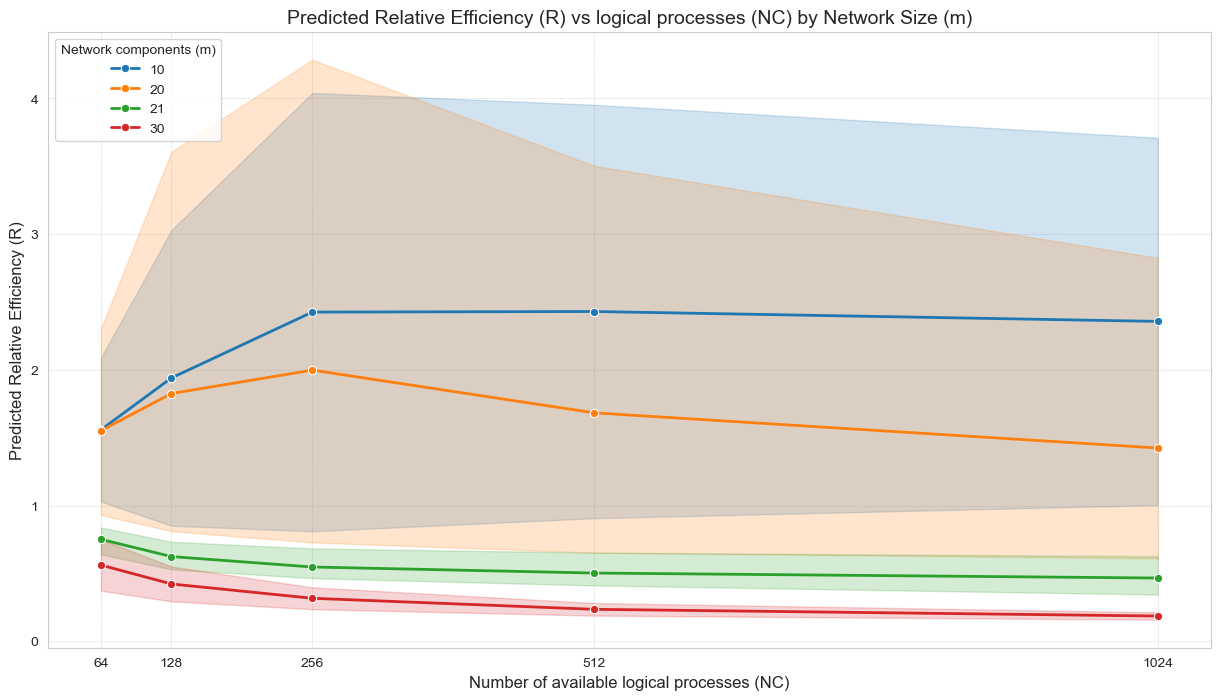

In [155]:
plt.figure(figsize=(15,8))
sns.lineplot(
    data = df_predict_normal,
    x = 'NC',
    y = 'Predicted_R',
    hue = 'm',
    palette = 'tab10',
    marker = 'o',
    linewidth = 2
)
plt.title('Predicted Relative Efficiency (R) vs logical processes (NC) by Network Size (m)', fontsize=14)
plt.xlabel('Number of available logical processes (NC)', fontsize=12)
plt.ylabel('Predicted Relative Efficiency (R)', fontsize=12)
plt.xticks(nc_values_raw, labels=nc_values_raw)
plt.grid(True, which="both", ls="--", linewidth=0.5, alpha=0.7)
plt.legend(title='Network components (m)')
plt.show()

# 10. Final Conclusions